# Анализ результатов трёхфакторной оценки машинных рефератов

Демонстрация работоспособности методики на конкретных примерах.

**Три кейса:**
1. Один документ — все диагнозы (максимальное разнообразие)
2. «Хороший» vs «Копирование» — сравнение рефератов
3. «Хороший» vs «Неполный» — сравнение рефератов

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, HTML
import textwrap
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'

In [15]:
# Загрузка данных
results = pd.read_csv('tsm-reference/full_analysis_results.csv')
data = pd.read_csv('data-tables/data-full.csv')

# Словари для отображения
MODEL_LABELS = {
    'summary_lingvo': 'Лингв.',
    'summary_TextRank': 'TextRank',
    'summary_LexRank': 'LexRank',
    'summary_mt5': 'mT5',
    'summary_mbart': 'mBART',
    'summary_rut5': 'ruT5',
    'summary_t5': 'T5',
}

DIAGNOSIS_LABELS = {
    'good': 'Целевая зона',
    'copying': 'Избыточное копирование',
    'incomplete': 'Семантическая неполнота',
    'under_compressed': 'Недостаточное сжатие',
    'over_compressed': 'Избыточное сжатие',
    'low_lexical': 'Низкое лекс. сходство',
    'ambiguous': 'Неоднозначный паттерн',
}

DIAGNOSIS_COLORS = {
    'good': '#27ae60',
    'copying': '#e74c3c',
    'incomplete': '#9b59b6',
    'under_compressed': '#e67e22',
    'over_compressed': '#f1c40f',
    'low_lexical': '#3498db',
    'ambiguous': '#95a5a6',
}

# Выбранные doc_id
CASE1_DOC = 111  # 5 разных диагнозов
CASE2_DOC = 247  # good vs copying
CASE3_DOC = 125  # good vs incomplete

print(f'Загружено: {len(results)} оценок, {len(data)} документов')
print(f'Модели: {results["model"].nunique()}, Документы: {results["doc_id"].nunique()}')

Загружено: 3353 оценок, 480 документов
Модели: 7, Документы: 479


## Общая картина: распределение диагнозов по моделям

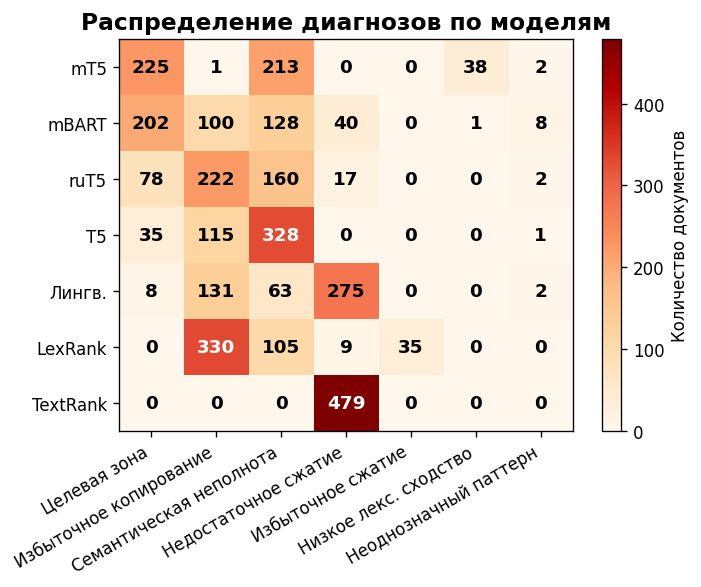

In [16]:
# Кросс-таблица: модель × диагноз
ct = pd.crosstab(results['model'], results['diagnosis_type'])

# Порядок
model_order = ['summary_mt5', 'summary_mbart', 'summary_rut5', 'summary_t5',
               'summary_lingvo', 'summary_LexRank', 'summary_TextRank']
diag_order = ['good', 'copying', 'incomplete', 'under_compressed', 'over_compressed', 'low_lexical', 'ambiguous']

# Фильтруем только существующие
model_order = [m for m in model_order if m in ct.index]
diag_order = [d for d in diag_order if d in ct.columns]
ct = ct.reindex(index=model_order, columns=diag_order, fill_value=0)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(ct.values, cmap='OrRd', aspect='auto')

ax.set_xticks(range(len(diag_order)))
ax.set_xticklabels([DIAGNOSIS_LABELS.get(d, d) for d in diag_order], rotation=30, ha='right')
ax.set_yticks(range(len(model_order)))
ax.set_yticklabels([MODEL_LABELS.get(m, m) for m in model_order])

for i in range(len(model_order)):
    for j in range(len(diag_order)):
        val = ct.values[i, j]
        color = 'white' if val > ct.values.max() * 0.6 else 'black'
        ax.text(j, i, str(val), ha='center', va='center', fontsize=11, fontweight='bold', color=color)

plt.colorbar(im, ax=ax, label='Количество документов')
ax.set_title('Распределение диагнозов по моделям', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'tsm-reference/figures/results_heatmap.png', dpi=300, bbox_inches='tight', facecolor='white', pad_inches=0.0)
plt.show()

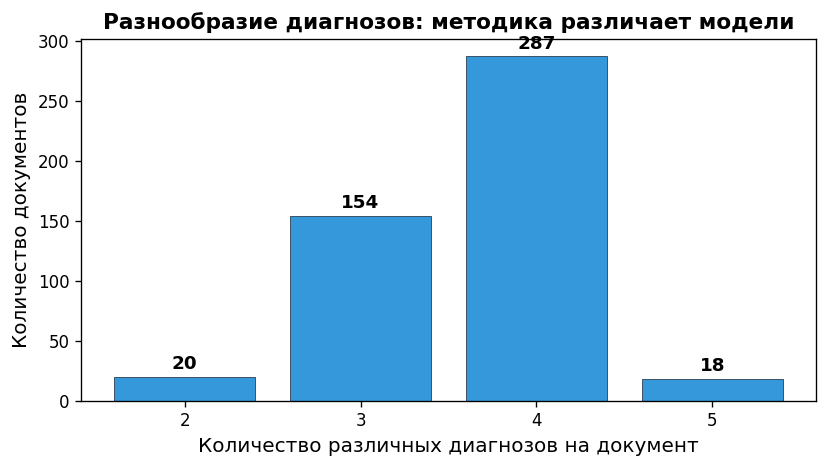

Медиана: 4 разных диагнозов на документ
Максимум: 5 разных диагнозов


In [4]:
# Разнообразие диагнозов: сколько разных диагнозов получает один документ
diag_per_doc = results.groupby('doc_id')['diagnosis_type'].nunique()

fig, ax = plt.subplots(figsize=(7, 4))
counts = diag_per_doc.value_counts().sort_index()
bars = ax.bar(counts.index, counts.values, color='#3498db', edgecolor='#2c3e50', linewidth=0.5)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel('Количество различных диагнозов на документ', fontsize=12)
ax.set_ylabel('Количество документов', fontsize=12)
ax.set_title('Разнообразие диагнозов: методика различает модели', fontsize=13, fontweight='bold')
ax.set_xticks(counts.index)
plt.tight_layout()
plt.show()

print(f'Медиана: {diag_per_doc.median():.0f} разных диагнозов на документ')
print(f'Максимум: {diag_per_doc.max()} разных диагнозов')

---
## Кейс 1: Один документ — пять диагнозов

Статья `doc_id=111` демонстрирует, как методика присваивает **разные диагнозы** рефератам от разных моделей для одного и того же исходного текста.

In [5]:
doc_id = CASE1_DOC
row = data.iloc[doc_id]

source = str(row['source_text'])
target = str(row['target_summary'])

# Информация о документе
print('━' * 70)
print(f'ДОКУМЕНТ doc_id={doc_id} (id={row["id"]})')
print('━' * 70)
print(f'Длина исходного текста: {len(source)} символов ({len(source.split())} слов)')
print(f'Длина авторского реферата: {len(target)} символов ({len(target.split())} слов)')
print(f'Степень сжатия (АР/ОТ): {len(target.split()) / len(source.split()):.3f}')
print()
print('НАЧАЛО ИСХОДНОГО ТЕКСТА:')
print('─' * 70)
# Показать первые ~300 символов
print(source[:400] + '...')
print()
print('АВТОРСКИЙ РЕФЕРАТ:')
print('─' * 70)
print(target[:500] + ('...' if len(target) > 500 else ''))

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ДОКУМЕНТ doc_id=111 (id=369)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Длина исходного текста: 28564 символов (3965 слов)
Длина авторского реферата: 752 символов (95 слов)
Степень сжатия (АР/ОТ): 0.024

НАЧАЛО ИСХОДНОГО ТЕКСТА:
──────────────────────────────────────────────────────────────────────
К ВОПРОСУ О ЛЕКСИЧЕСКОЙ ОРГАНИЗАЦИИ ТЕКСТА:
ОПЫТ ПРОЧТЕНИЯ РАССКАЗА И.А. БУНИНА «СОСНЫ»
На сегодняшний день изучение текста остается одной из актуальных и
интереснейших задач современной лингвистики. Модели и методики анализа
художественного текста неоднократно предлагались разными исследователями ([1–7] и др.), но специфика, многогранность, глубина предмета изучения не позволяют остановиться и вы...

АВТОРСКИЙ РЕФЕРАТ:
──────────────────────────────────────────────────────────────────────
В статье исследуется лексическая организация текста на материале рассказа
И.А. Бунина «Сосны». Через функц

In [15]:
# Таблица результатов для doc_id
sub = results[results['doc_id'] == doc_id].copy()
sub['model_label'] = sub['model'].map(MODEL_LABELS)
sub['diag_label'] = sub['diagnosis_type'].map(DIAGNOSIS_LABELS)
sub = sub.sort_values('Q', ascending=False)

display_cols = ['model_label', 'diag_label', 'Q', 'z_lex', 'z_sem', 'z_comp',
                'diagnosis_confidence']
display_df = sub[display_cols].copy()
display_df.columns = ['Модель', 'Диагноз', 'Q', 'z_lex', 'z_sem', 'z_comp', 'Уверенность']

# Округление
for col in ['Q', 'z_lex', 'z_sem', 'z_comp', 'Уверенность']:
    display_df[col] = display_df[col].round(3)

# HTML таблица с цветами
def color_row(row_data, diag_type):
    color = DIAGNOSIS_COLORS.get(diag_type, '#ffffff')
    return f'background-color: {color}22; border-left: 4px solid {color}'

html = '<table style="border-collapse: collapse; width: 100%; font-size: 13px;">'
html += '<tr style="background: #2c3e50; color: white;">'
for col in display_df.columns:
    html += f'<th style="padding: 8px 12px; text-align: center;">{col}</th>'
html += '</tr>'

for idx, (_, drow) in enumerate(display_df.iterrows()):
    diag_type = sub.iloc[idx]['diagnosis_type']
    style = color_row(drow, diag_type)
    html += f'<tr style="{style};">'
    for col in display_df.columns:
        val = drow[col]
        align = 'left' if col in ['Модель', 'Диагноз'] else 'center'
        html += f'<td style="padding: 6px 12px; text-align: {align}; border-bottom: 1px solid #ddd;">{val}</td>'
    html += '</tr>'
html += '</table>'

display(HTML(html))

Модель,Диагноз,Q,z_lex,z_sem,z_comp,Уверенность
ruT5,Целевая зона,0.534,-0.205,0.133,0.15,0.818
mT5,Низкое лекс. сходство,0.436,-1.554,-0.714,-0.398,0.149
Лингво,Копирование,0.285,1.858,0.826,1.382,0.357
LexRank,Копирование,0.277,2.736,1.496,-0.535,0.998
mBART,Неполнота,0.241,-0.174,-1.846,0.339,0.427
T5,Неполнота,0.157,2.091,-2.301,0.241,0.779
TextRank,Недостаточное сжатие,0.022,2.736,-2.007,8.413,1.0


In [9]:
print(html)

<table style="border-collapse: collapse; width: 100%; font-size: 13px;"><tr style="background: #2c3e50; color: white;"><th style="padding: 8px 12px; text-align: center;">Модель</th><th style="padding: 8px 12px; text-align: center;">Диагноз</th><th style="padding: 8px 12px; text-align: center;">Q</th><th style="padding: 8px 12px; text-align: center;">z_lex</th><th style="padding: 8px 12px; text-align: center;">z_sem</th><th style="padding: 8px 12px; text-align: center;">z_comp</th><th style="padding: 8px 12px; text-align: center;">Уверенность</th></tr><tr style="background-color: #27ae6022; border-left: 4px solid #27ae60;"><td style="padding: 6px 12px; text-align: left; border-bottom: 1px solid #ddd;">ruT5</td><td style="padding: 6px 12px; text-align: left; border-bottom: 1px solid #ddd;">Целевая зона</td><td style="padding: 6px 12px; text-align: center; border-bottom: 1px solid #ddd;">0.534</td><td style="padding: 6px 12px; text-align: center; border-bottom: 1px solid #ddd;">-0.205</td

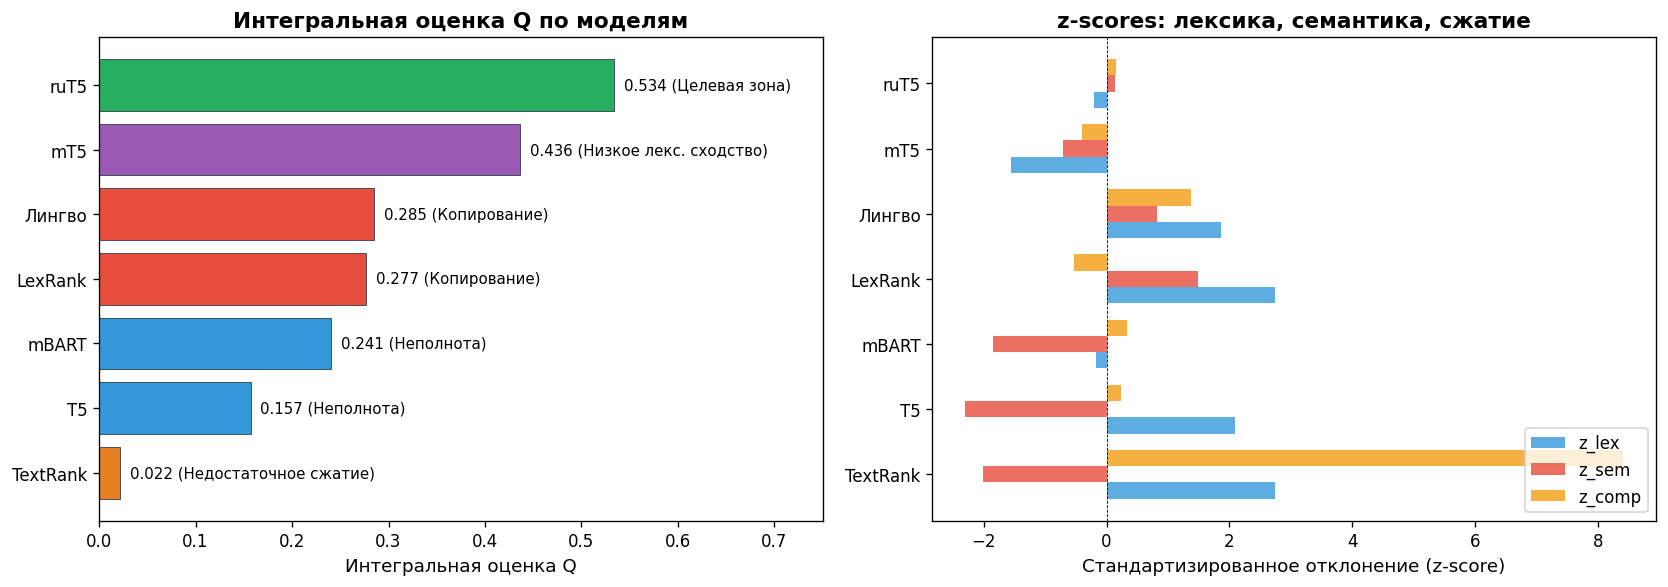

In [25]:
# Визуализация: столбчатая диаграмма Q и z-scores для каждой модели
sub = results[results['doc_id'] == CASE1_DOC].copy()
sub['model_label'] = sub['model'].map(MODEL_LABELS)
sub = sub.sort_values('Q', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Левый: Q по моделям
ax = axes[0]
colors = [DIAGNOSIS_COLORS.get(d, '#ccc') for d in sub['diagnosis_type']]
bars = ax.barh(sub['model_label'], sub['Q'], color=colors, edgecolor='#2c3e50', linewidth=0.5)
ax.set_xlabel('Интегральная оценка Q', fontsize=11)
ax.set_title('Интегральная оценка Q по моделям', fontsize=13, fontweight='bold')
ax.set_xlim(0, 0.75)

for bar, q, diag in zip(bars, sub['Q'], sub['diagnosis_type']):
    label = DIAGNOSIS_LABELS.get(diag, diag)
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{q:.3f} ({label})', va='center', fontsize=9)

# Правый: z-scores
ax = axes[1]
x = np.arange(len(sub))
w = 0.25
ax.barh(x - w, sub['z_lex'].values, w, label='z_lex', color='#3498db', alpha=0.8)
ax.barh(x,     sub['z_sem'].values, w, label='z_sem', color='#e74c3c', alpha=0.8)
ax.barh(x + w, sub['z_comp'].values, w, label='z_comp', color='#f39c12', alpha=0.8)

ax.set_yticks(x)
ax.set_yticklabels(sub['model_label'])
ax.set_xlabel('Стандартизированное отклонение (z-score)', fontsize=11)
ax.set_title('z-scores: лексика, семантика, сжатие', fontsize=13, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.5, linestyle='--')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(f'figures/results_example.png', dpi=300, bbox_inches='tight', facecolor='white', pad_inches=0.5)
plt.show()

In [16]:
# Сравнение фрагментов рефератов
doc_id = CASE1_DOC
row = data.iloc[doc_id]
sub = results[results['doc_id'] == doc_id].sort_values('Q', ascending=False)

target = str(row['target_summary'])

html = '<h3>Сравнение фрагментов рефератов</h3>'
html += f'<div style="background: #f0f0f0; padding: 12px; margin: 8px 0; border-radius: 6px; border-left: 4px solid #2c3e50;">'
html += f'<b>Авторский реферат</b> ({len(target)} симв.):<br>'
html += f'<i>{target}</i></div>' # [:400]}{"..." if len(target) > 400 else ""

for _, r in sub.iterrows():
    model = r['model']
    diag = r['diagnosis_type']
    q = r['Q']
    conf = r['diagnosis_confidence']
    color = DIAGNOSIS_COLORS.get(diag, '#ccc')
    label = MODEL_LABELS.get(model, model)
    diag_label = DIAGNOSIS_LABELS.get(diag, diag)

    text = str(row.get(model, ''))
    if not text or text == 'nan':
        continue

    html += f'<div style="background: {color}11; padding: 12px; margin: 8px 0; border-radius: 6px; border-left: 4px solid {color};">'
    html += f'<b>{label}</b> — <span style="color: {color}; font-weight: bold;">{diag_label}</span>'
    html += f' (Q={q:.3f}, уверенность={conf:.2f}, {len(text)} симв.)<br>'
    html += f'<i>{text}</i></div>' # [:350]}{"..." if len(text) > 350 else ""

display(HTML(html))
# print(html)

---
## Кейс 2: «Хороший» vs «Копирование»

Статья `doc_id=247`: модель **mT5** получила диагноз `good` (Q=0.546), а **Лингво** — `copying` (Q=0.147).

Методика обнаруживает, что один реферат передаёт смысл оригинала своими словами, а другой — дословно копирует фрагменты.

In [93]:
doc_id = 297 # CASE2_DOC # 208
row = data.iloc[doc_id]
sub = results[results['doc_id'] == doc_id].copy()
sub['model_label'] = sub['model'].map(MODEL_LABELS)
sub['diag_label'] = sub['diagnosis_type'].map(DIAGNOSIS_LABELS)
sub = sub.sort_values('Q', ascending=False)

source = str(row['source_text'])
target = str(row['target_summary'])

print('━' * 70)
print(f'ДОКУМЕНТ doc_id={doc_id}')
print('━' * 70)
print(f'Исходный текст: {len(source)} символов')
print(f'Авторский реферат: {len(target)} символов')
print()

# Таблица всех моделей
display_cols = ['model_label', 'diag_label', 'Q', 'z_lex', 'z_sem', 'z_comp', 'diagnosis_confidence']
display_df = sub[display_cols].copy()
display_df.columns = ['Модель', 'Диагноз', 'Q', 'z_lex', 'z_sem', 'z_comp', 'Уверенность']
for col in ['Q', 'z_lex', 'z_sem', 'z_comp', 'Уверенность']:
    display_df[col] = display_df[col].round(3)

html = '<table style="border-collapse: collapse; width: 100%; font-size: 13px;">'
html += '<tr style="background: #2c3e50; color: white;">'
for col in display_df.columns:
    html += f'<th style="padding: 8px 12px; text-align: center;">{col}</th>'
html += '</tr>'
for idx, (_, drow) in enumerate(display_df.iterrows()):
    diag_type = sub.iloc[idx]['diagnosis_type']
    color = DIAGNOSIS_COLORS.get(diag_type, '#ffffff')
    bg = f'{color}22'
    html += f'<tr style="background-color: {bg}; border-left: 4px solid {color};">'
    for col in display_df.columns:
        val = drow[col]
        bold = ' font-weight: bold;' if col in ['Модель', 'Диагноз'] else ''
        align = 'left' if col in ['Модель', 'Диагноз'] else 'center'
        html += f'<td style="padding: 6px 12px; text-align: {align};{bold} border-bottom: 1px solid #ddd;">{val}</td>'
    html += '</tr>'
html += '</table>'
display(HTML(html))

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ДОКУМЕНТ doc_id=297
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Исходный текст: 13927 символов
Авторский реферат: 1115 символов



Модель,Диагноз,Q,z_lex,z_sem,z_comp,Уверенность
mT5,Целевая зона,0.463,-0.415,-0.639,0.574,0.511
mBART,Копирование,0.378,1.461,-0.271,0.41,0.067
LexRank,Копирование,0.363,2.736,-0.176,-0.149,0.998
ruT5,Копирование,0.338,1.969,0.416,0.887,0.438
T5,Копирование,0.255,1.497,-1.196,0.246,0.093
Лингво,Недостаточное сжатие,0.253,2.542,0.687,2.021,0.379
TextRank,Недостаточное сжатие,0.001,2.736,-3.589,6.394,1.0


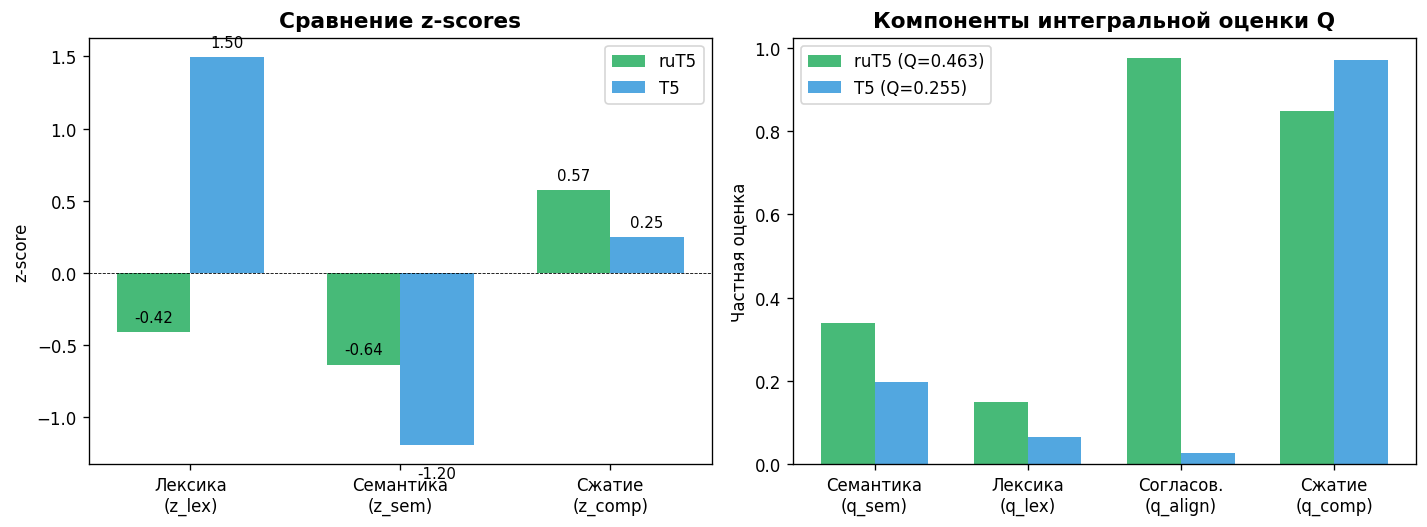

In [97]:
good_model = 'summary_mt5'
# good_model = 'summary_mbart'
# good_model = 'summary_t5'
# good_model = 'summary_rut5'

# bad_model = 'summary_lingvo'
# bad_model = 'summary_LexRank'
# bad_model = 'summary_rut5'
bad_model = 'summary_t5'
# bad_model = 'summary_mbart'

good_text = str(row[good_model])
bad_text = str(row[bad_model])

good_row = sub[sub['model'] == good_model].iloc[0]
bad_row = sub[sub['model'] == bad_model].iloc[0]


# Визуализация: сравнение «good» vs «copying»
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Левый: сравнение z-scores
metrics = ['z_lex', 'z_sem', 'z_comp']
metric_labels = ['Лексика\n(z_lex)', 'Семантика\n(z_sem)', 'Сжатие\n(z_comp)']
x = np.arange(len(metrics))
w = 0.35

good_vals = [good_row[m] for m in metrics]
bad_vals = [bad_row[m] for m in metrics]

bars1 = axes[0].bar(x - w/2, good_vals, w, label=f'ruT5', color='#27ae60', alpha=0.85)
bars2 = axes[0].bar(x + w/2, bad_vals, w, label=f'T5', color='#3498db', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_labels)
axes[0].set_ylabel('z-score')
axes[0].set_title('Сравнение z-scores', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].axhline(y=0, color='black', linewidth=0.5, linestyle='--')

# Добавить значения
for bar, val in zip(bars1, good_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars2, bad_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05 if val >= 0 else bar.get_height() - 0.15,
                 f'{val:.2f}', ha='center', va='bottom' if val >= 0 else 'top', fontsize=9)

# Правый: компоненты Q
q_parts = ['q_sem', 'q_lex', 'q_align', 'q_comp']
q_labels = ['Семантика\n(q_sem)', 'Лексика\n(q_lex)', 'Согласов.\n(q_align)', 'Сжатие\n(q_comp)']
x2 = np.arange(len(q_parts))

good_q = [good_row[q] for q in q_parts]
bad_q = [bad_row[q] for q in q_parts]

bars3 = axes[1].bar(x2 - w/2, good_q, w, label=f'ruT5 (Q={good_row["Q"]:.3f})', color='#27ae60', alpha=0.85)
bars4 = axes[1].bar(x2 + w/2, bad_q, w, label=f'T5 (Q={bad_row["Q"]:.3f})', color='#3498db', alpha=0.85)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(q_labels)
axes[1].set_ylabel('Частная оценка')
axes[1].set_title('Компоненты интегральной оценки Q', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

In [95]:
# Сопоставление текстов
html = '<h3>Сопоставление фрагментов: good vs copying</h3>'

html += '<div style="padding: 12px; margin: 8px 0; border-radius: 6px; border-left: 4px solid #2c3e50;">' # background: #f0f0f0; 
html += f'<b>Авторский реферат</b> ({len(target)} симв.):<br>'
html += f'<i>{target}</i></div>' # [:500]}{"..." if len(target) > 500 else ""

color_g = DIAGNOSIS_COLORS['good']
html += f'<div style="background: {color_g}15; padding: 12px; margin: 8px 0; border-radius: 6px; border-left: 4px solid {color_g};">'
html += f'<b>{good_model}</b> (Q={good_row["Q"]:.3f}, z_lex={good_row["z_lex"]:.2f}, z_sem={good_row["z_sem"]:.2f})<br>'
html += f'<i>{good_text}</i></div>' # [:500]}{"..." if len(good_text) > 500 else ""

color_b = DIAGNOSIS_COLORS['copying']
html += f'<div style="background: {color_b}15; padding: 12px; margin: 8px 0; border-radius: 6px; border-left: 4px solid {color_b};">'
html += f'<b>{bad_model}</b> (Q={bad_row["Q"]:.3f}, z_lex={bad_row["z_lex"]:.2f}, z_sem={bad_row["z_sem"]:.2f})<br>'
html += f'<span style="color:#666;">Обратите внимание: высокое лексическое сходство (z_lex={bad_row["z_lex"]:.2f}) указывает на дословное копирование фрагментов первоисточника.</span><br><br>'
html += f'<i>{bad_text}</i></div>' # [:500]}{"..." if len(bad_text) > 500 else ""

# Подсчитаем лексическое пересечение (грубая оценка)
source_words = set(source.lower().split())
good_words = set(good_text.lower().split())
bad_words = set(bad_text.lower().split())

good_overlap = len(good_words & source_words) / max(len(good_words), 1)
bad_overlap = len(bad_words & source_words) / max(len(bad_words), 1)

html += f'<div style="background: #fff3cd; padding: 10px; margin: 8px 0; border-radius: 6px; border-left: 4px solid #ffc107;">'
html += f'<b>Лексическое пересечение с первоисточником:</b><br>'
html += f'mT5 (good): {good_overlap:.1%} слов совпадают<br>'
html += f'Лингво (copying): {bad_overlap:.1%} слов совпадают</div>'

display(HTML(html))

---
## Кейс 3: «Хороший» vs «Неполный»

Статья `doc_id=125`: модель **mT5** получила диагноз `good` (Q=0.534), а **ruT5** — `incomplete` (Q=0.076).

Методика показывает, что один реферат полноценно отражает содержание статьи, а другой упускает ключевые аспекты.

In [98]:
doc_id = 425 #243 #CASE3_DOC
row = data.iloc[doc_id]
sub = results[results['doc_id'] == doc_id].copy()
sub['model_label'] = sub['model'].map(MODEL_LABELS)
sub['diag_label'] = sub['diagnosis_type'].map(DIAGNOSIS_LABELS)
sub = sub.sort_values('Q', ascending=False)

source = str(row['source_text'])
target = str(row['target_summary'])

print('━' * 70)
print(f'ДОКУМЕНТ doc_id={doc_id}')
print('━' * 70)
print(f'Исходный текст: {len(source)} символов')
print(f'Авторский реферат: {len(target)} символов')
print()

# Таблица
display_cols = ['model_label', 'diag_label', 'Q', 'z_lex', 'z_sem', 'z_comp', 'diagnosis_confidence']
display_df = sub[display_cols].copy()
display_df.columns = ['Модель', 'Диагноз', 'Q', 'z_lex', 'z_sem', 'z_comp', 'Уверенность']
for col in ['Q', 'z_lex', 'z_sem', 'z_comp', 'Уверенность']:
    display_df[col] = display_df[col].round(3)

html = '<table style="border-collapse: collapse; width: 100%; font-size: 13px;">'
html += '<tr style="background: #2c3e50; color: white;">'
for col in display_df.columns:
    html += f'<th style="padding: 8px 12px; text-align: center;">{col}</th>'
html += '</tr>'
for idx, (_, drow) in enumerate(display_df.iterrows()):
    diag_type = sub.iloc[idx]['diagnosis_type']
    color = DIAGNOSIS_COLORS.get(diag_type, '#ffffff')
    bg = f'{color}22'
    html += f'<tr style="background-color: {bg}; border-left: 4px solid {color};">'
    for col in display_df.columns:
        val = drow[col]
        bold = ' font-weight: bold;' if col in ['Модель', 'Диагноз'] else ''
        align = 'left' if col in ['Модель', 'Диагноз'] else 'center'
        html += f'<td style="padding: 6px 12px; text-align: {align};{bold} border-bottom: 1px solid #ddd;">{val}</td>'
    html += '</tr>'
html += '</table>'
display(HTML(html))

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ДОКУМЕНТ doc_id=425
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Исходный текст: 5864 символов
Авторский реферат: 466 символов



Модель,Диагноз,Q,z_lex,z_sem,z_comp,Уверенность
ruT5,Копирование,0.388,2.162,0.047,0.706,0.579
LexRank,Копирование,0.38,2.736,-0.491,-0.038,0.998
mBART,Копирование,0.342,1.432,1.425,1.216,0.046
mT5,Низкое лекс. сходство,0.313,-3.518,-0.322,-0.606,1.0
Лингво,Недостаточное сжатие,0.251,2.387,0.283,2.313,0.577
T5,Неполнота,0.21,0.197,-2.624,0.256,1.0
TextRank,Недостаточное сжатие,0.181,2.736,1.079,7.896,1.0


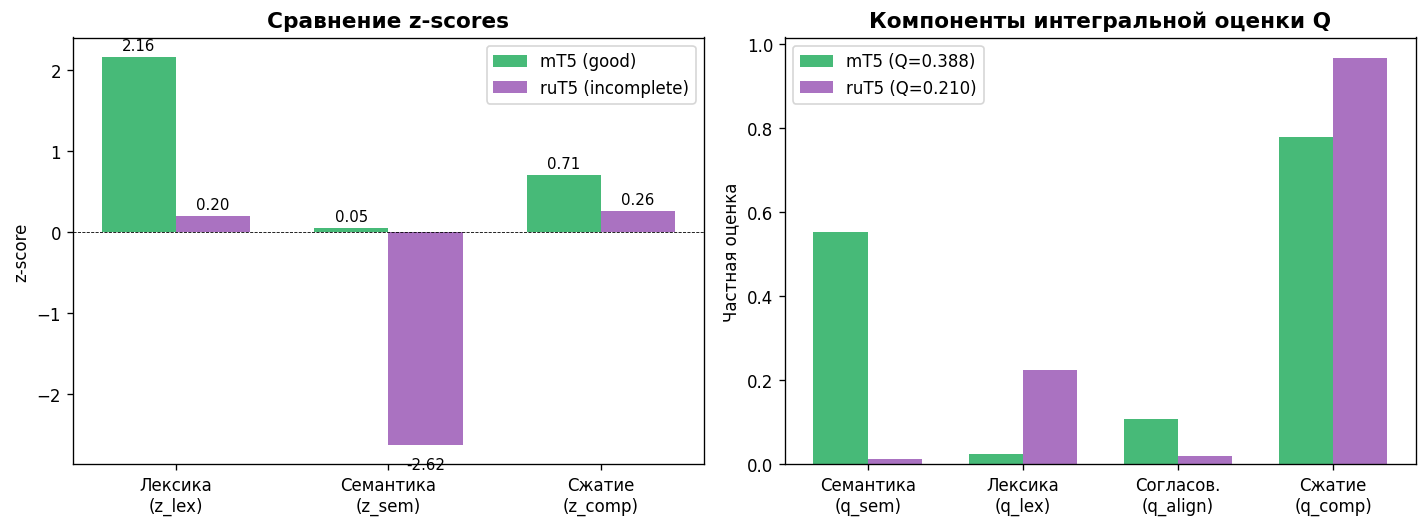

In [100]:
# good_model = 'summary_mt5'
good_model = 'summary_rut5'
# good_model = 'summary_LexRank'
# good_model = 'summary_mbart'

# bad_model = 'summary_mbart'
bad_model = 'summary_t5'

good_text = str(row[good_model])
bad_text = str(row[bad_model])

good_row_c3 = sub[sub['model'] == good_model].iloc[0]
bad_row_c3 = sub[sub['model'] == bad_model].iloc[0]

# Визуализация: сравнение good vs incomplete
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

metrics = ['z_lex', 'z_sem', 'z_comp']
metric_labels = ['Лексика\n(z_lex)', 'Семантика\n(z_sem)', 'Сжатие\n(z_comp)']
x = np.arange(len(metrics))
w = 0.35

good_vals = [good_row_c3[m] for m in metrics]
bad_vals = [bad_row_c3[m] for m in metrics]

bars1 = axes[0].bar(x - w/2, good_vals, w, label='mT5 (good)', color='#27ae60', alpha=0.85)
bars2 = axes[0].bar(x + w/2, bad_vals, w, label='ruT5 (incomplete)', color='#9b59b6', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_labels)
axes[0].set_ylabel('z-score')
axes[0].set_title('Сравнение z-scores', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].axhline(y=0, color='black', linewidth=0.5, linestyle='--')

for bar, val in zip(bars1, good_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars2, bad_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05 if val >= 0 else bar.get_height() - 0.15,
                 f'{val:.2f}', ha='center', va='bottom' if val >= 0 else 'top', fontsize=9)

q_parts = ['q_sem', 'q_lex', 'q_align', 'q_comp']
q_labels = ['Семантика\n(q_sem)', 'Лексика\n(q_lex)', 'Согласов.\n(q_align)', 'Сжатие\n(q_comp)']
x2 = np.arange(len(q_parts))

good_q = [good_row_c3[q] for q in q_parts]
bad_q = [bad_row_c3[q] for q in q_parts]

bars3 = axes[1].bar(x2 - w/2, good_q, w, label=f'mT5 (Q={good_row_c3["Q"]:.3f})', color='#27ae60', alpha=0.85)
bars4 = axes[1].bar(x2 + w/2, bad_q, w, label=f'ruT5 (Q={bad_row_c3["Q"]:.3f})', color='#9b59b6', alpha=0.85)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(q_labels)
axes[1].set_ylabel('Частная оценка')
axes[1].set_title('Компоненты интегральной оценки Q', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

In [91]:
# Сопоставление текстов
html = '<h3>Сопоставление фрагментов: good vs incomplete</h3>'

html += '<div style="padding: 12px; margin: 8px 0; border-radius: 6px; border-left: 4px solid #2c3e50;">' # background: #f0f0f0; 
html += f'<b>Авторский реферат</b> ({len(target)} симв.):<br>'
html += f'<i>{target}</i></div>'

color_g = DIAGNOSIS_COLORS['good']
html += f'<div style="background: {color_g}15; padding: 12px; margin: 8px 0; border-radius: 6px; border-left: 4px solid {color_g};">'
html += f'<b>mT5 — Хороший</b> (Q={good_row_c3["Q"]:.3f}, z_lex={good_row_c3["z_lex"]:.2f}, z_sem={good_row_c3["z_sem"]:.2f}, {len(good_text)} симв.)<br>'
html += f'<i>{good_text}</i></div>'

color_b = DIAGNOSIS_COLORS['incomplete']
html += f'<div style="background: {color_b}15; padding: 12px; margin: 8px 0; border-radius: 6px; border-left: 4px solid {color_b};">'
html += f'<b>ruT5 — Неполный</b> (Q={bad_row_c3["Q"]:.3f}, z_lex={bad_row_c3["z_lex"]:.2f}, z_sem={bad_row_c3["z_sem"]:.2f})<br>'
# html += f'<span style="color:#666;">Обратите внимание: низкая семантическая близость (z_sem={bad_row_c3["z_sem"]:.2f}) указывает на потерю ключевой информации.</span><br><br>'
html += f'<i>{bad_text}</i></div>'

# Длины
html += f'<div style="background: #fff3cd; padding: 10px; margin: 8px 0; border-radius: 6px; border-left: 4px solid #ffc107;">'
html += f'<b>Длины рефератов:</b><br>'
html += f'Авторский: {len(target.split())} слов<br>'
html += f'mT5 (good): {len(good_text.split())} слов<br>'
html += f'ruT5 (incomplete): {len(bad_text.split())} слов</div>'

display(HTML(html))

---
## Обзорная визуализация: все три кейса на общем графике

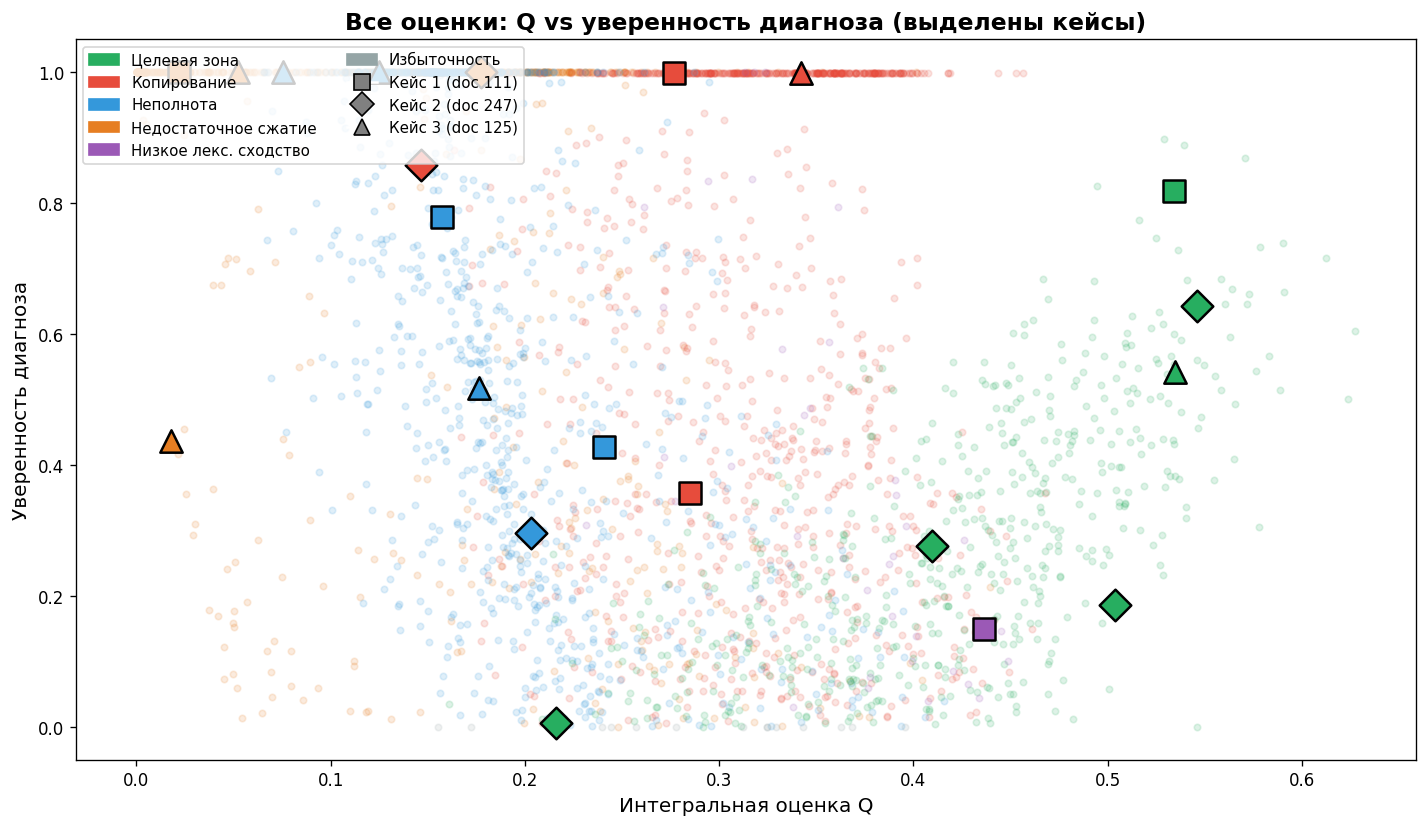

In [15]:
# Scatter: Q vs diagnosis_confidence с выделением трёх кейсов
fig, ax = plt.subplots(figsize=(12, 7))

# Все точки (фон)
for diag in results['diagnosis_type'].unique():
    mask = results['diagnosis_type'] == diag
    color = DIAGNOSIS_COLORS.get(diag, '#ccc')
    label = DIAGNOSIS_LABELS.get(diag, diag)
    ax.scatter(results.loc[mask, 'Q'], results.loc[mask, 'diagnosis_confidence'],
               c=color, alpha=0.15, s=15, label=label)

# Выделенные кейсы
case_docs = {CASE1_DOC: 'Кейс 1', CASE2_DOC: 'Кейс 2', CASE3_DOC: 'Кейс 3'}
markers = {CASE1_DOC: 's', CASE2_DOC: 'D', CASE3_DOC: '^'}

for doc_id, case_label in case_docs.items():
    sub = results[results['doc_id'] == doc_id]
    for _, r in sub.iterrows():
        color = DIAGNOSIS_COLORS.get(r['diagnosis_type'], '#ccc')
        ax.scatter(r['Q'], r['diagnosis_confidence'],
                   c=color, s=180, marker=markers[doc_id],
                   edgecolors='black', linewidths=1.5, zorder=5)

# Легенда диагнозов
handles = [mpatches.Patch(color=DIAGNOSIS_COLORS[d], label=DIAGNOSIS_LABELS[d])
           for d in ['good', 'copying', 'incomplete', 'under_compressed', 'low_lexical', 'ambiguous']
           if d in results['diagnosis_type'].values]

# Маркеры кейсов
from matplotlib.lines import Line2D
case_handles = [
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=10,
           markeredgecolor='black', label='Кейс 1 (doc 111)'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='gray', markersize=10,
           markeredgecolor='black', label='Кейс 2 (doc 247)'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markersize=10,
           markeredgecolor='black', label='Кейс 3 (doc 125)'),
]

ax.legend(handles=handles + case_handles, loc='upper left', fontsize=9, ncol=2)
ax.set_xlabel('Интегральная оценка Q', fontsize=12)
ax.set_ylabel('Уверенность диагноза', fontsize=12)
ax.set_title('Все оценки: Q vs уверенность диагноза (выделены кейсы)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

---
## Выводы

Трёхфакторная методика оценки демонстрирует:

1. **Дифференцирующую способность**: для одного и того же документа разные модели получают разные, адекватные диагнозы (до 5 типов из 7).

2. **Детектирование копирования**: методика чётко отличает рефераты, перефразирующие оригинал (good), от рефератов, дословно копирующих фрагменты (copying), через фактор лексического сходства (z_lex).

3. **Детектирование неполноты**: методика выявляет рефераты, упускающие ключевую информацию (incomplete), через фактор семантической близости (z_sem).

4. **Согласованность метрик**: интегральная оценка Q корректно отражает общее качество, а отдельные z-scores позволяют объяснить *почему* реферат получил конкретный диагноз.

5. **Устойчивость на разных типах текстов**: примеры взяты из разных предметных областей (лингвистика, техника, право), что подтверждает универсальность методики.